### Code for Brownian Motion

In [1]:
import numpy as np
import matplotlib.pyplot as plt
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (16, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

### Simulation of a Brownian Motion

Let $W_t$ denote the Brownian motion, then:

$$
    W_t = W_0 + \int_0^tdW_s \approx W_0 + \sum_{k=0}^{N-1}(W_{k+1} - W_k) = W_0 + \sum_{k=0}^{N-1}\Delta_k, \quad \Delta_k\sim \mathcal{N}(0,\Delta t)
$$ where $W_N$ is the $N$-th point in the discrete process. We consider an interval $[0, 1]$ with $\Delta t = 10^3$; therefore, $N = 1000$.

In [ ]:
np.random.seed(10);

for _ in range(5):
    W0 = 0.0
    N = 1000
    ts = np.linspace(0.0, 1.0, N+1)
    dt = ts[1]-ts[0]
    W = np.zeros(N+1)
    for i in range(1, N+1):
        W[i] = W[i-1] + dt * np.random.randn()
    plt.figure(1, figsize=(16, 5));
    if _ == 0:
        _label = r'$\Delta t={}$'.format(np.round(dt, 4))
    else:
        _label = ''
    plt.plot(
        ts, W, '-', lw=2.0, label=_label
    );
    plt.axhline(0.0, linestyle='--', color='red');
    plt.xticks(fontsize=16);
    plt.yticks(fontsize=16);
    plt.xlabel(r'$t$', fontsize=16); plt.ylabel(r'$W_t$', fontsize=16); 
    plt.title('Brownian motion in 1D', fontsize=24);
    plt.legend(fontsize=16);
plt.savefig('./BrownianMotionDemo.png', dpi=300);

### Simulate Fake Brownian Motion

$$
    dX_t = -\lambda X_tdt  + \sigma_t dW_t
$$

We let $\lambda = 1$, $\sigma_t = \sqrt{1+2t}$, $X_0 = 0$, we integrate from $t\in [0,5]$, with $\Delta t = 0.005$.

In [ ]:
np.random.seed(10);
for _ in range(5):
    lam = 1
    sigma = lambda x: np.sqrt(2*x+1)
    x0 = 0
    nt = 1000
    ts = np.linspace(0, 5.0, nt+1)
    dt = ts[1]-ts[0]
    x = np.zeros(nt+1)
    for i in range(1, nt+1):
        x[i] = x[i-1] - lam*x[i-1]*dt + sigma(ts[i-1])*np.sqrt(dt)*np.random.randn()
    plt.figure(1, figsize=(16, 5));
    if _ == 0:
        _label = r'$\Delta t={}$'.format(np.round(dt, 4))
    else:
        _label = ''
    plt.plot(
        ts, x, '-', lw=2.0, label=_label
    );
    plt.axhline(0.0, linestyle='--', color='red');
    plt.xticks(fontsize=16);
    plt.yticks(fontsize=16);
    plt.xlabel(r'$t$', fontsize=16); plt.ylabel(r'$X_t$', fontsize=16); 
    plt.title('Not a Brownian Motion', fontsize=24);
    plt.legend(fontsize=16);
plt.savefig('./NotBrownianMotionDemo.png', dpi=300);

In [ ]:
# compute a sample covariance
np.random.seed(10);
nmc = 10000  # compute 1000 paths
lam = 1
sigma = lambda x: np.sqrt(2*x+1)
x0 = 0
nt = 1000
ts = np.linspace(0, 5.0, nt+1)
dt = ts[1]-ts[0]
x = np.zeros([nmc, nt+1])
# vectorized
for j in range(1, nt+1):
    x[:, j] = (x[:, j-1].reshape(-1, 1) - lam*x[:, j-1].reshape(-1, 1)*dt + \
               sigma(ts[j-1])*np.sqrt(dt)*np.random.randn(nmc, 1).reshape(-1, 1)).flatten()
# for each increment, estimate covariance 
cov = np.zeros(nt+1)
for j in range(1, nt):
    cov[j] = np.cov(x[:, j], x[:, j+1]-x[:, j])[0, 1]

In [ ]:
plt.figure(1);
plt.plot(ts[:-1], cov[:-1], color='red', lw=1.5);
plt.xlabel(r'$t$', fontsize=16); plt.ylabel(r'$\text{Cov}(X_{t+\Delta t} - X_t, X_t)$', fontsize=16);
plt.xticks(fontsize=16); plt.yticks(fontsize=16);
plt.savefig('./NotBrownianMotion_Covariance.png', dpi=300, bbox_inches='tight');

### Fit Brownian Motion to Stock Price

In [ ]:
import yfinance as yf
import pandas as pd

We use maximum likelihood fit to the data, with the linear trend model:

$$
    X_t = \mu t + \sigma W_t    
$$ where $W_t$ is standard Brownian motion.

Suppose we observe on a uniform grid $t_0 < t_1 < \cdots < t_n$ the points $x_0, x_1,\dots, x_n$, with spacing $\Delta t = t_{i+1}-t_i$. We have:

$$
    \Delta X_i = X_{t_i} - X_{t_{i-1}} = \mu\Delta t + \sigma (W_{t_i} - W_{t_{i-1}}) \sim \mathcal{N}(\mu\Delta, \sigma^2\Delta t)
$$

Therefore, we can find the best fit parameters $\mu, \sigma$ using maximum likelihood.

[*********************100%***********************]  1 of 1 completed


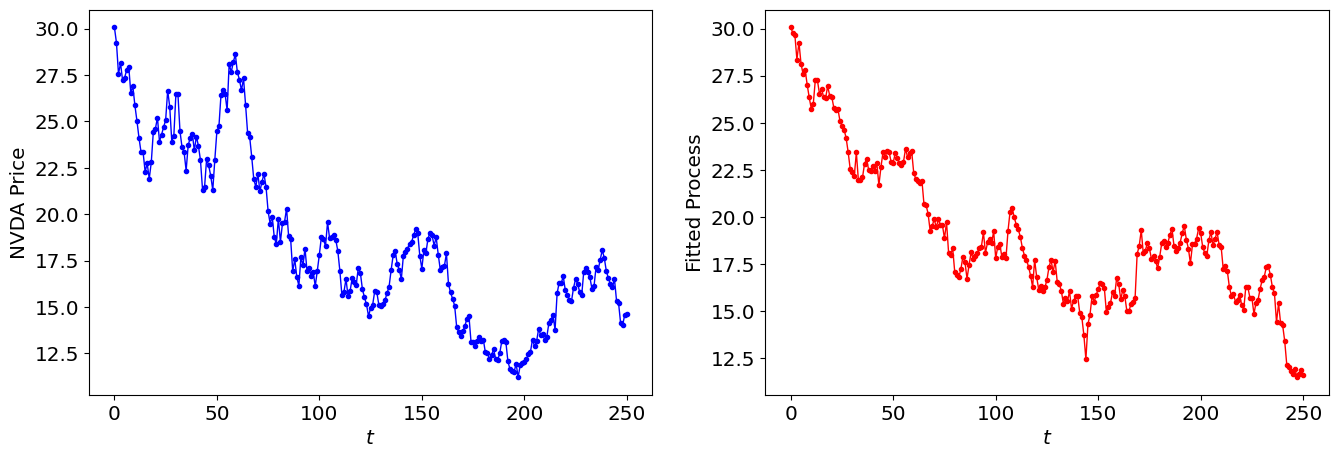

In [3]:
import yfinance as yf
ticker = "NVDA"
start_date = "2022-01-01"
end_date = "2023-01-01"
dt = 1

# Download the stock data
nvda_data = yf.download(ticker, start=start_date, end=end_date)
price = nvda_data['Adj Close'].to_numpy()
n = len(price)-1

# compute best fit parameters
dx = price[1:]-price[0:-1]
mu = np.mean(dx/dt)
sigma = np.sum((dx-dt*mu)**2)/dt/(n-1)

fig, ax = plt.subplots(1, 2, figsize=(16, 5));
ax[0].plot(price, linestyle='-', marker='o', markersize=3, color='blue', lw=1.0);
ax[0].set_xlabel(r'$t$'); ax[0].set_ylabel('NVDA Price');

# sample the fitted process
np.random.seed(2);
x0 = price[0]
x = np.zeros(n+1)
x[0] = x0
ts = np.arange(n+1)
for i in range(1, n+1):
    x[i] = x[i-1] + mu*dt + sigma*np.sqrt(dt)*np.random.randn()

ax[1].plot(ts, x, linestyle='-', marker='o', markersize=3, color='red', lw=1.0);
ax[1].set_xlabel(r'$t$'); ax[1].set_ylabel('Fitted Process');

# compute a best fit using linear trend
plt.savefig('./linear_brownian_motion_fit.png', dpi=300, bbox_inches='tight');

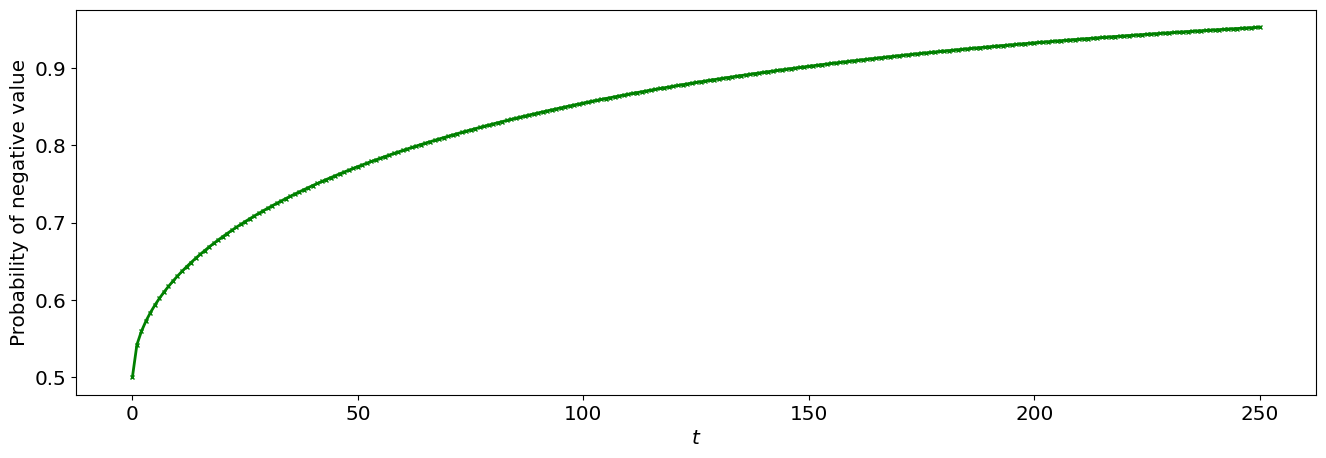

In [8]:
# visualizing the CDF
import scipy
import scipy.stats
z = -mu / sigma * (ts**0.5)
plt.plot(scipy.stats.norm.cdf(z), marker='x', lw=2.0, markersize=2.5, color='green');
plt.xlabel(r'$t$'); plt.ylabel(r'Probability of negative value'); 
plt.savefig('negative_value_prob.png', dpi=300, bbox_inches='tight');